In [ ]:
# Upload your activities.csv file
from google.colab import files
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("📁 Please upload your activities.csv file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {filename}")
print(f"📊 File size: {len(uploaded[filename]):,} bytes")

# Quick preview of the raw data
df_preview = pd.read_csv(filename)
print(f"\n📋 Data shape: {df_preview.shape[0]} activities, {df_preview.shape[1]} columns")
print(f"📅 Date range: {df_preview['Activity Date'].min()} to {df_preview['Activity Date'].max()}")

📁 Please upload your activities.csv file:


Saving activities.csv to activities.csv

✅ Uploaded: activities.csv
📊 File size: 564,683 bytes

📋 Data shape: 1550 activities, 99 columns
📅 Date range: Apr 1, 2020, 3:50:55 PM to Sep 9, 2025, 11:13:36 PM


In [ ]:
# Define all data processing functions

def load_and_initial_clean(filepath):
    """Load the raw Strava CSV and perform initial cleaning."""
    print("Loading data from:", filepath)
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df)} activities with {len(df.columns)} columns")

    # Remove completely empty rows if any
    df = df.dropna(how='all')

    # Convert Activity Date to datetime
    df['Activity Date'] = pd.to_datetime(df['Activity Date'], errors='coerce')

    return df

def select_core_features(df):
    """Select only the core features needed for modeling."""
    # Define core columns to keep (if they exist in the data)
    core_columns = [
        'Activity Date', 'Activity Type', 'Moving Time'
    ]

    # Keep only columns that exist in the dataframe
    existing_columns = [col for col in core_columns if col in df.columns]
    df_selected = df[existing_columns].copy()

    print(f"\nSelected {len(existing_columns)} core features from {len(df.columns)} total columns")

    # Handle duplicate column names
    df_selected = df_selected.loc[:, ~df_selected.columns.duplicated()]

    return df_selected

def analyze_missing_data(df):
    """Analyze missing data patterns and create a report."""
    missing_report = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
    })

    missing_report = missing_report.sort_values('Missing_Percentage', ascending=False)
    missing_report['Imputation_Method'] = missing_report['Missing_Percentage'].apply(
        lambda x: 'Dropped (>50% missing)' if x > 50 else 'Mean imputation' if x > 0 else 'No imputation needed'
    )

    return missing_report

def convert_time_to_seconds(time_str):
  """Convert time string (HH:MM:SS or MM:SS) to total seconds."""
  if pd.isna(time_str) or time_str == '':
    return np.nan

  # If it's already numeric, return it
  if isinstance(time_str, (int, float)):
      return float(time_str)

  # Convert string to seconds
  try:
      time_str = str(time_str)
      parts = time_str.split(':')

      if len(parts) == 3:  # HH:MM:SS
          hours, minutes, seconds = parts
          return float(hours) * 3600 + float(minutes) * 60 + float(seconds)
      elif len(parts) == 2:  # MM:SS
          minutes, seconds = parts
          return float(minutes) * 60 + float(seconds)
      elif len(parts) == 1:  # Just seconds
          return float(parts[0])
      else:
          return np.nan
  except:
      return np.nan

def engineer_features(df):
  """Create derived features for better model performance."""
  print("\nEngineering new features...")

  # Convert time columns from string format to seconds if needed
  time_columns = ['Moving Time']
  for col in time_columns:
      if col in df.columns:
          # Check if column is string type
          if df[col].dtype == 'object':
              print(f"  Converting {col} from time string to seconds...")
              df[col] = df[col].apply(convert_time_to_seconds)

  # Convert Distance to numeric if it's not already
  if 'Distance' in df.columns:
      df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

  # 4. Time-based features
  if 'Activity Date' in df.columns:
      df['weekday'] = df['Activity Date'].dt.dayofweek  # 0=Monday, 6=Sunday
      df['month'] = df['Activity Date'].dt.month
      df['year'] = df['Activity Date'].dt.year
      df['day_of_year'] = df['Activity Date'].dt.dayofyear

  print(f"Created features successfully!")

  return df

def normalize_features(df):
    """Normalize numeric features using z-score normalization."""
    print("\nNormalizing numeric features...")

    # Identify numeric columns to normalize (exclude binary flags and identifiers)
    exclude_from_norm = [
        'is_race', 'has_heart_rate', 'has_power', 'has_cadence',
        'weekday', 'month', 'year', 'day_of_year'
    ]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_normalize = [col for col in numeric_cols if col not in exclude_from_norm]

    # Z-score normalization
    for col in cols_to_normalize:
        if df[col].std() > 0:  # Avoid division by zero
            df[f'{col}_normalized'] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[f'{col}_normalized'] = 0

    print(f"Normalized {len(cols_to_normalize)} features")

    return df

def create_final_dataset(df):
  """Create the final model-ready dataset by selecting and ordering columns."""
  print("\nCreating final dataset...")

  # Define column order (features first, then target-related)
  priority_cols = ['Activity Date', 'Activity Type', 'Moving Time']

  # Get all numeric and engineered features
  feature_cols = [col for col in df.columns if col not in priority_cols]

  # Reorder columns
  final_cols = priority_cols + feature_cols
  final_cols = [col for col in final_cols if col in df.columns]

  df_final = df[final_cols].copy()

  # Sort by Activity Date (most recent first)
  if 'Activity Date' in df_final.columns:
      df_final = df_final.sort_values('Activity Date', ascending=False)

  print(f"Final dataset shape: {df_final.shape}")

  return df_final

In [ ]:
# RUN THE COMPLETE PROCESSING PIPELINE

print("=" * 60)
print("🚀 STRAVA DATA PROCESSING PIPELINE")
print("=" * 60)

# Step 1: Load data
df = load_and_initial_clean(filename)

# Step 2: Select core features
df = select_core_features(df)

# Step 4: Engineer features (no race detection)
df = engineer_features(df)

# Step 6: Normalize features
df = normalize_features(df)

# Step 8: Create final dataset
activities = create_final_dataset(df)

# Step 9: Save outputs
activities.to_csv('strava_model_ready.csv', index=False)

print("\n" + "=" * 60)
print("✅ PROCESSING COMPLETE!")
print("=" * 60)
print(f"\nDataset Summary:")
print(f"  📊 Total training activities: {len(activities)}")
print(f"  🔢 Total features: {len(activities.columns)}")
print(f"  📈 Numeric features: {len(activities.select_dtypes(include=[np.number]).columns)}")
print(f"  📝 Text features kept: {len(activities.select_dtypes(include=['object']).columns)}")

🚀 STRAVA DATA PROCESSING PIPELINE
Loading data from: activities.csv
Loaded 1550 activities with 99 columns

Selected 3 core features from 99 total columns

Engineering new features...
Created features successfully!

Normalizing numeric features...
Normalized 1 features

Creating final dataset...
Final dataset shape: (1550, 8)

✅ PROCESSING COMPLETE!

Dataset Summary:
  📊 Total training activities: 1550
  🔢 Total features: 8
  📈 Numeric features: 6
  📝 Text features kept: 1


In [ ]:
# Explore the processed data
print("📋 First 5 rows of processed data:")
activities.head()

📋 First 5 rows of processed data:


,Activity Date,Activity Type,Moving Time,weekday,month,year,day_of_year,Moving Time_normalized
1547,2025-10-19 13:37:35,Hike,11853.0,6,10,2025,292,4.160320
1546,2025-10-18 18:37:34,Run,380.0,5,10,2025,291,-1.172302
1548,2025-10-18 13:29:38,Hike,21695.0,5,10,2025,291,8.734857
1549,2025-10-17 17:12:20,Hike,12559.0,4,10,2025,290,4.488467
1545,2025-10-16 20:02:20,Ride,6075.0,3,10,2025,289,1.474720


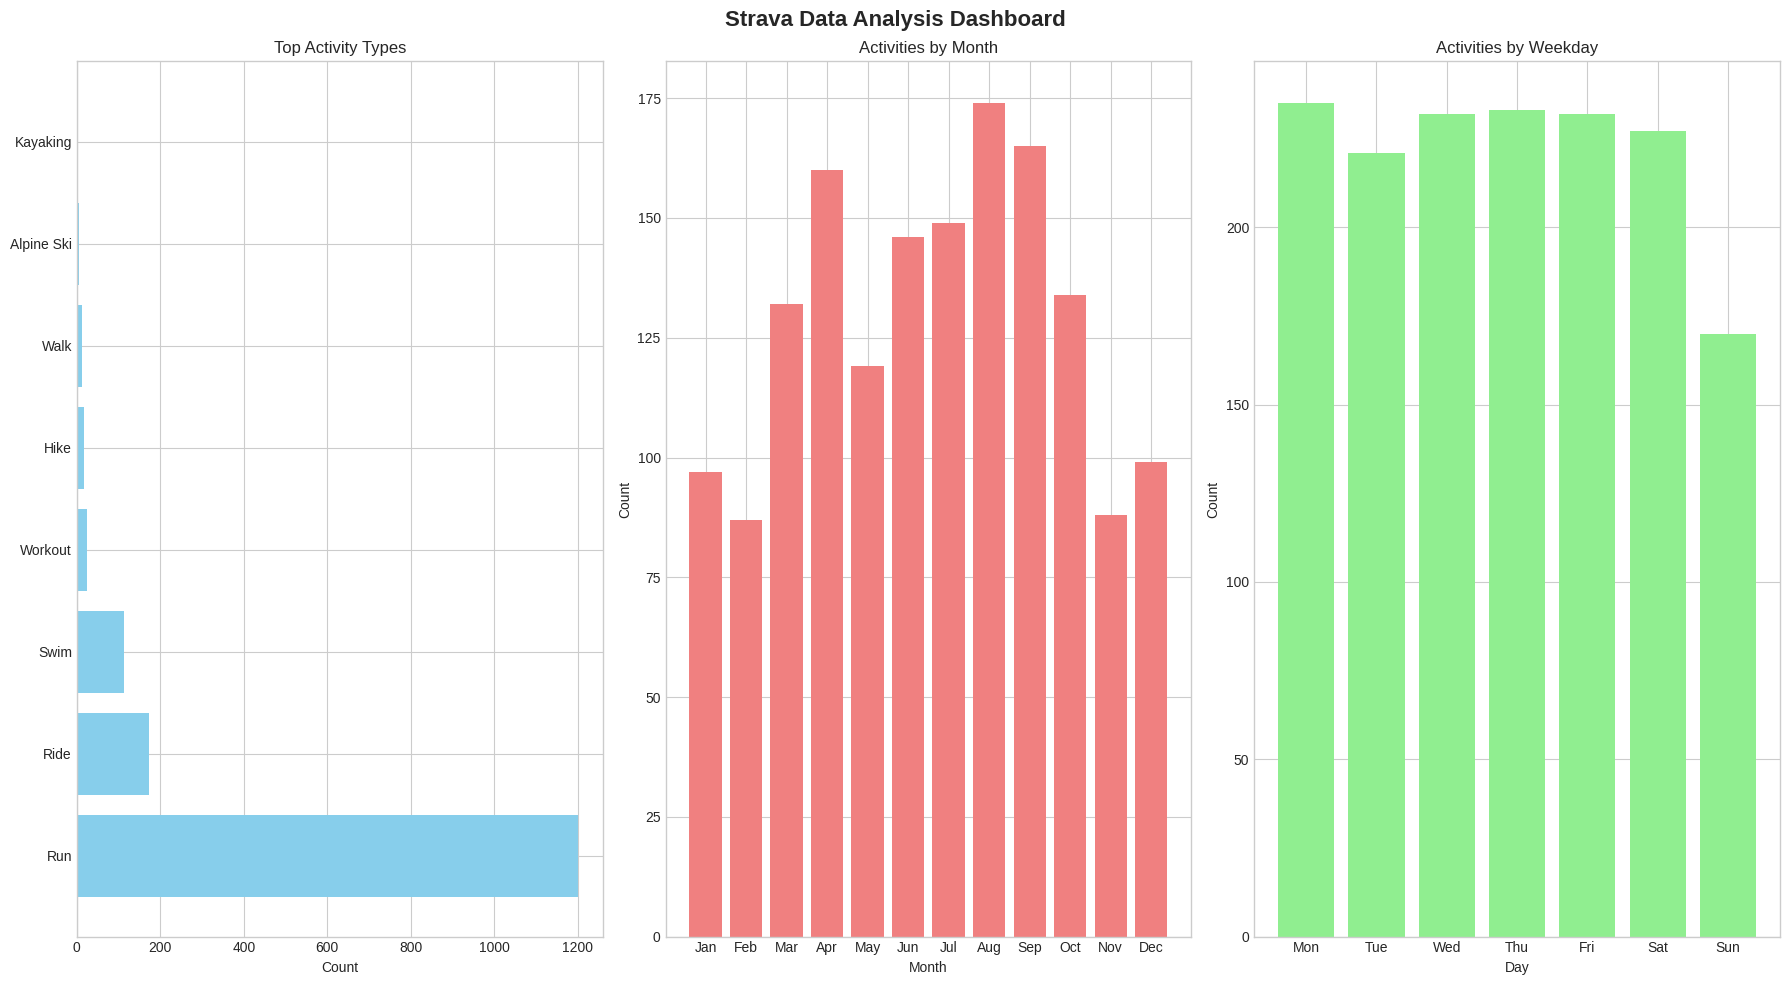

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Strava Data Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Activity Types Distribution
if 'Activity Type' in activities.columns:
    activity_counts = activities['Activity Type'].value_counts().head(8)
    axes[0].barh(activity_counts.index, activity_counts.values, color='skyblue')
    axes[0].set_title('Top Activity Types')
    axes[0].set_xlabel('Count')

# 2. Monthly Activity Pattern
if 'month' in activities.columns:
    monthly = activities['month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1].bar(monthly.index, monthly.values, color='lightcoral')
    axes[1].set_title('Activities by Month')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Count')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels([month_names[i-1] for i in monthly.index])

# 3. Weekday Distribution
if 'weekday' in activities.columns:
    weekday = activities['weekday'].value_counts().sort_index()
    day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[2].bar(weekday.index, weekday.values, color='lightgreen')
    axes[2].set_title('Activities by Weekday')
    axes[2].set_xlabel('Day')
    axes[2].set_ylabel('Count')
    axes[2].set_xticks(range(7))
    axes[2].set_xticklabels(day_names)

plt.tight_layout()
plt.show()

In [ ]:
# Show statistics for key features
print("📊 Key Feature Statistics:")
print("=" * 60)

key_features = ['Moving Time']
available_features = [col for col in key_features if col in activities.columns]

stats_df = activities[available_features].describe()
print(stats_df.round(2))

📊 Key Feature Statistics:
       Moving Time
count      1550.00
mean       2902.18
std        2151.47
min          24.00
25%        1736.50
50%        2495.00
75%        3558.00
max       21695.00


In [ ]:
# Download the processed files to your computer
from google.colab import files

print("💾 Ready to download your processed files!\n")
print("File 1: strava_model_ready.csv - Your clean, ML-ready dataset")
print("File 2: missing_data_report.csv - Data quality report\n")

files.download('strava_model_ready.csv')
files.download('missing_data_report.csv')

print("\n✅ Files downloaded successfully!")

💾 Ready to download your processed files!

File 1: strava_model_ready.csv - Your clean, ML-ready dataset
File 2: missing_data_report.csv - Data quality report



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: missing_data_report.csv

In [ ]:
# --- SETUP ---
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# If running in Google Colab:
from google.colab import files

# --- STEP 1: Load user-selected race data ---
print("📁 Please upload your race spreadsheet (e.g. andrew_race_times.xlsx):")
uploaded = files.upload()

race_filename = list(uploaded.keys())[0]
print(f"\n✅ Loaded race file: {race_filename}")

races = pd.read_excel(race_filename)
print(f"📊 Race dataset shape: {races.shape}")



📁 Please upload your race spreadsheet (e.g. andrew_race_times.xlsx):


Saving andrew_race_times.xlsx to andrew_race_times.xlsx

✅ Loaded race file: andrew_race_times.xlsx
📊 Race dataset shape: (5, 10)


In [ ]:
def time_to_seconds(t):
    if pd.isna(t):
        return np.nan
    if isinstance(t, (int, float)):
        return t
    parts = str(t).split(':')
    if len(parts) == 3:
        h, m, s = parts
        return int(h)*3600 + int(m)*60 + float(s)
    elif len(parts) == 2:
        m, s = parts
        return int(m)*60 + float(s)
    return np.nan

# Apply conversion
for col in ['Swim', 'Bike', 'Run', 'Total']:
    if col in races.columns:
        races[col + ' (s)'] = races[col].apply(time_to_seconds)

races['Date'] = pd.to_datetime(races['Date'])

In [ ]:
activities['Activity Date'] = pd.to_datetime(activities['Activity Date'])

def total_training_hours(df, race_date, sport, days=60):      # 60 DAYS IS A KEY PARAMETER TO PLAY WITH!
    mask = (
        (df['Activity Type'].str.lower() == sport) &
        (df['Activity Date'] < race_date) &
        (df['Activity Date'] >= race_date - pd.Timedelta(days=days))
    )
    return df.loc[mask, 'Moving Time'].sum() / 3600  # convert sec → hours

train_features = []
for _, row in races.iterrows():
    race_date = row['Date']
    swim_h = total_training_hours(activities, race_date, 'swim')
    bike_h = total_training_hours(activities, race_date, 'ride')
    run_h  = total_training_hours(activities, race_date, 'run')

    train_features.append({
        'Race Date': race_date,
        'swim_hours': swim_h,
        'bike_hours': bike_h,
        'run_hours': run_h,
        'race_time_sec': row['Total (s)']
    })

df_train = pd.DataFrame(train_features)

df_train['weighted_volume'] = (         # WEIGHTS OF EACH SPORT ARE A KEY PARAMETER TO PLAY WITH!
    0.3 * df_train['swim_hours'] +
    0.4 * df_train['bike_hours'] +
    0.3 * df_train['run_hours']
)

df_train.head()


,Race Date,swim_hours,bike_hours,run_hours,race_time_sec,weighted_volume
0,2023-07-23,1.756667,14.076389,29.985278,8669.0,15.153139
1,2023-09-23,1.575000,9.066111,29.353056,8911.0,12.904861
2,2024-04-14,5.878333,15.729167,18.754444,8063.0,13.681500
3,2025-03-29,3.949444,10.945556,15.753056,8216.0,10.288972
4,2025-09-21,3.570278,29.346111,21.071111,8103.0,19.130861


In [ ]:
X = df_train[['weighted_volume']]
y = df_train['race_time_sec']


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer

# Define model
model = LinearRegression()

# Define 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=5)     #CHANGING NUMBER OF FOLDS IS A VALID PARAMETER TO PLAY WITH

# Define custom scorers
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Compute cross-validated scores
mae_scores = cross_val_score(model, X, y, cv=cv, scoring=mae_scorer)
r2_scores = cross_val_score(model, X, y, cv=cv, scoring=r2_scorer)

print(f"Mean MAE: {abs(mae_scores.mean()):.2f} seconds")
print(f"Mean R²: {r2_scores.mean():.3f}")

# Fit model on full dataset to inspect coefficients
model.fit(X, y)
print(f"Coefficient: {model.coef_[0]:.2f} seconds/hour")
print(f"Intercept: {model.intercept_:.2f} seconds")

Mean MAE: 565.14 seconds
Mean R²: nan
Coefficient: -22.95 seconds/hour
Intercept: 8718.98 seconds


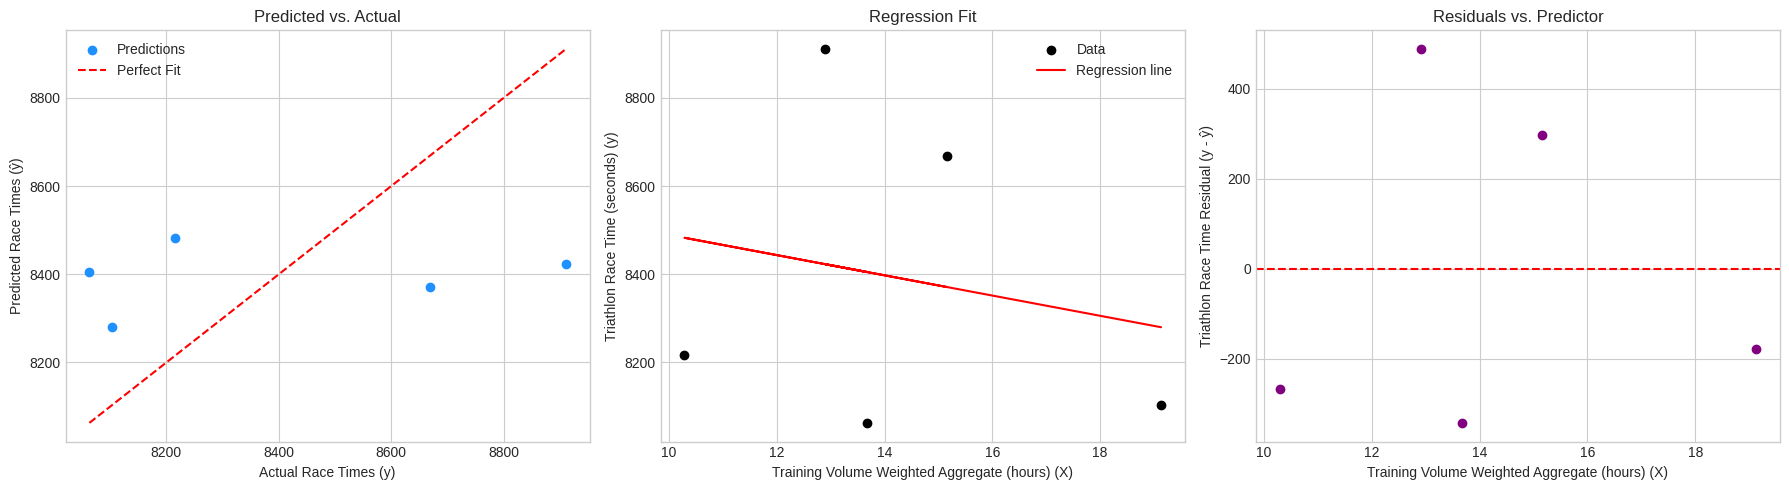

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get model predictions on full dataset
y_pred = model.predict(X)
residuals = y - y_pred

# --- Create 1x3 subplot layout ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1️⃣ Predicted vs Actual ---
axes[0].scatter(y, y_pred, color='dodgerblue', label='Predictions')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
axes[0].set_xlabel("Actual Race Times (y)")
axes[0].set_ylabel("Predicted Race Times (ŷ)")
axes[0].set_title("Predicted vs. Actual")
axes[0].legend()
axes[0].grid(True)

# --- 2️⃣ Regression line ---
axes[1].scatter(X, y, color='black', label='Data')
axes[1].plot(X, y_pred, color='red', label='Regression line')
axes[1].set_xlabel("Training Volume Weighted Aggregate (hours) (X)")
axes[1].set_ylabel("Triathlon Race Time (seconds) (y)")
axes[1].set_title("Regression Fit")
axes[1].legend()
axes[1].grid(True)

# --- 3️⃣ Residuals plot ---
axes[2].scatter(X, residuals, color='purple')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel("Training Volume Weighted Aggregate (hours) (X)")
axes[2].set_ylabel("Triathlon Race Time Residual (y - ŷ)")
axes[2].set_title("Residuals vs. Predictor")
axes[2].grid(True)

plt.tight_layout()
plt.show()
